In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from datasets import load_dataset

# "distractor" = each question ships with a bounded set of ~10 paragraphs,
# not the entire Wikipedia — that's what we need, since we'll be editing
# that context to inject contradictions/misinformation later.
# "validation" = the dev/test-style split (HuggingFace calls it "validation").
dataset = load_dataset("hotpotqa/hotpot_qa", "distractor", split="validation")

print(dataset)        # shows row count and field names
print(dataset[0])     # one real example, so we can see the actual structure

/Users/skmazhit/truth-distortion-llm/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'],
    num_rows: 7405
})
{'id': '5a8b57f25542995d1e6f1371', 'question': 'Were Scott Derrickson and Ed Wood of the same nationality?', 'answer': 'yes', 'type': 'comparison', 'level': 'hard', 'supporting_facts': {'title': ['Scott Derrickson', 'Ed Wood'], 'sent_id': [0, 0]}, 'context': {'title': ['Ed Wood (film)', 'Scott Derrickson', 'Woodson, Arkansas', 'Tyler Bates', 'Ed Wood', 'Deliver Us from Evil (2014 film)', 'Adam Collis', 'Sinister (film)', 'Conrad Brooks', 'Doctor Strange (2016 film)'], 'sentences': [['Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.', " The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.", ' Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, an

In [3]:
example = dataset[0]

print("QUESTION:", example["question"])
print("ANSWER:", example["answer"])
print()

print("Number of paragraphs in context:", len(example["context"]["title"]))
print("Paragraph titles:", example["context"]["title"])
print()

print("SUPPORTING FACTS (the sentences that actually justify the answer):")
for title, sent_id in zip(example["supporting_facts"]["title"], example["supporting_facts"]["sent_id"]):
    print(f"  - '{title}', sentence #{sent_id}")
print()

print("First paragraph, sentence by sentence:")
for i, sentence in enumerate(example["context"]["sentences"][0]):
    print(f"  [{i}] {sentence}")

QUESTION: Were Scott Derrickson and Ed Wood of the same nationality?
ANSWER: yes

Number of paragraphs in context: 10
Paragraph titles: ['Ed Wood (film)', 'Scott Derrickson', 'Woodson, Arkansas', 'Tyler Bates', 'Ed Wood', 'Deliver Us from Evil (2014 film)', 'Adam Collis', 'Sinister (film)', 'Conrad Brooks', 'Doctor Strange (2016 film)']

SUPPORTING FACTS (the sentences that actually justify the answer):
  - 'Scott Derrickson', sentence #0
  - 'Ed Wood', sentence #0

First paragraph, sentence by sentence:
  [0] Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.
  [1]  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.
  [2]  Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.


In [4]:
def get_supporting_sentences(example):
    """
    Resolve each supporting fact to its actual sentence text.

    Titles in supporting_facts must be matched by NAME against context
    titles, not by position — as we just saw, they don't line up.
    """
    titles = example["context"]["title"]
    sentences_by_paragraph = example["context"]["sentences"]

    resolved = []
    for sf_title, sf_sent_id in zip(
        example["supporting_facts"]["title"],
        example["supporting_facts"]["sent_id"],
    ):
        para_index = titles.index(sf_title)
        sentence_text = sentences_by_paragraph[para_index][sf_sent_id]
        resolved.append((sf_title, sentence_text))
    return resolved


for title, sentence in get_supporting_sentences(example):
    print(f"[{title}] {sentence}")


[Scott Derrickson] Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.
[Ed Wood] Edward Davis Wood Jr. (October 10, 1924 – December 10, 1978) was an American filmmaker, actor, writer, producer, and director.


In [5]:
def build_prompt(example):
    """
    Format a HotpotQA example as a QA prompt.

    Important: we include ALL 10 context paragraphs, not just the 2
    relevant ones. That's the whole point of the "distractor" setting --
    the model has to find the right evidence among 8 irrelevant
    paragraphs, not just read 2 given facts. This is what we'll later
    corrupt to create the noisy/adversarial conditions.
    """
    paragraphs = []
    for title, sentences in zip(example["context"]["title"], example["context"]["sentences"]):
        paragraph_text = " ".join(sentences)
        paragraphs.append(f"{title}: {paragraph_text}")

    context_block = "\n\n".join(paragraphs)

    return f"""Answer the question using ONLY the information in the paragraphs below. Give a short, direct answer.

{context_block}

Question: {example['question']}
Answer:"""


prompt = build_prompt(example)
print(prompt)

Answer the question using ONLY the information in the paragraphs below. Give a short, direct answer.

Ed Wood (film): Ed Wood is a 1994 American biographical period comedy-drama film directed and produced by Tim Burton, and starring Johnny Depp as cult filmmaker Ed Wood.  The film concerns the period in Wood's life when he made his best-known films as well as his relationship with actor Bela Lugosi, played by Martin Landau.  Sarah Jessica Parker, Patricia Arquette, Jeffrey Jones, Lisa Marie, and Bill Murray are among the supporting cast.

Scott Derrickson: Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.  He lives in Los Angeles, California.  He is best known for directing horror films such as "Sinister", "The Exorcism of Emily Rose", and "Deliver Us From Evil", as well as the 2016 Marvel Cinematic Universe installment, "Doctor Strange."

Woodson, Arkansas: Woodson is a census-designated place (CDP) in Pulaski County, Arkansas, in the United Sta

In [6]:
import sys
sys.path.append("..")

from src.models.ollama_client import OllamaClient

client = OllamaClient(model_name="llama3.1:8b")
model_answer = client.generate(prompt)

print("MODEL ANSWERED:", model_answer)
print("GOLD ANSWER:", example["answer"])

MODEL ANSWERED: Yes. Both were American.
GOLD ANSWER: yes


In [7]:
def corrupt_fact(client, true_sentence, subject):
    """
    Rewrite a true supporting-fact sentence into a plausible-but-false
    version, with the subject's name held fixed.

    Without this constraint, the model tends to swap out the subject
    entirely (e.g. "Scott Derrickson" -> "Scott Spielberg") rather than
    keeping the same person and lying about one attribute of them --
    which breaks the controlled, single-fact-change design we want.
    """
    corruption_prompt = f"""Rewrite the sentence below so it states something FALSE about {subject}, by changing exactly ONE fact (a date, place, nationality, or role). Do NOT change the name "{subject}" itself. Keep the same style and length. Output ONLY the rewritten sentence -- no quotes, no explanation, no preamble.

Sentence: {true_sentence}

Rewritten sentence:"""
    corrupted = client.generate(corruption_prompt).strip()
    return corrupted.strip('"')


true_sentence = "Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer."
fake_sentence = corrupt_fact(client, true_sentence, subject="Scott Derrickson")

print("TRUE:", true_sentence)
print("FAKE:", fake_sentence)

TRUE: Scott Derrickson (born July 16, 1966) is an American director, screenwriter and producer.
FAKE: Scott Derrickson (born August 16, 1971) is a British director, screenwriter and actor.


In [8]:
import copy

def create_noisy_context(client, example, fact_index=0):
    """
    Return a corrupted copy of example's context, with exactly one
    supporting-fact SENTENCE swapped for a false version.

    fact_index picks WHICH supporting fact to corrupt (0 = the first).
    Everything else -- every other sentence, every other paragraph,
    all titles -- stays byte-identical to the original.
    """
    title = example["supporting_facts"]["title"][fact_index]
    sent_id = example["supporting_facts"]["sent_id"][fact_index]
    para_index = example["context"]["title"].index(title)

    true_sentence = example["context"]["sentences"][para_index][sent_id]
    fake_sentence = corrupt_fact(client, true_sentence, subject=title)

    # deep copy -- we must NOT mutate the original example, since we
    # still need its clean version for the baseline condition
    noisy_context = copy.deepcopy(example["context"])
    noisy_context["sentences"][para_index][sent_id] = fake_sentence

    return noisy_context, para_index, true_sentence, fake_sentence


noisy_context, para_index, true_sentence, fake_sentence = create_noisy_context(client, example, fact_index=0)

print(f"Corrupted paragraph ({noisy_context['title'][para_index]}):")
for i, sentence in enumerate(noisy_context["sentences"][para_index]):
    marker = " <-- CHANGED" if i == 0 else ""
    print(f"  [{i}] {sentence}{marker}")

Corrupted paragraph (Scott Derrickson):
  [0] Scott Derrickson (born August 16, 1971) is a British director, screenwriter and actor. <-- CHANGED
  [1]  He lives in Los Angeles, California.
  [2]  He is best known for directing horror films such as "Sinister", "The Exorcism of Emily Rose", and "Deliver Us From Evil", as well as the 2016 Marvel Cinematic Universe installment, "Doctor Strange."


In [9]:
def build_prompt(example, context=None):
    """
    (Updated from before.) Pass a `context` override to build the prompt
    from a modified version of the context -- this is how we reuse the
    same function for baseline, noisy, and adversarial conditions
    without duplicating it three times.
    """
    if context is None:
        context = example["context"]

    paragraphs = []
    for title, sentences in zip(context["title"], context["sentences"]):
        paragraph_text = " ".join(sentences)
        paragraphs.append(f"{title}: {paragraph_text}")

    context_block = "\n\n".join(paragraphs)

    return f"""Answer the question using ONLY the information in the paragraphs below. Give a short, direct answer.

{context_block}

Question: {example['question']}
Answer:"""


noisy_prompt = build_prompt(example, context=noisy_context)
noisy_answer = client.generate(noisy_prompt)

print("BASELINE ANSWER:", model_answer)
print("NOISY ANSWER:   ", noisy_answer)
print("GOLD ANSWER:    ", example["answer"])


BASELINE ANSWER: Yes. Both were American.
NOISY ANSWER:    Yes. Both were American.
GOLD ANSWER:     yes


In [10]:
from src.data.loader import load_hotpotqa, get_supporting_sentences
from src.data.distortion import corrupt_fact, create_noisy_context
from src.data.prompting import build_prompt

noisy_context, para_index, true_sentence, fake_sentence = create_noisy_context(client, example, fact_index=0)

baseline_prompt = build_prompt(example)
noisy_prompt = build_prompt(example, context=noisy_context)

baseline_answer = client.generate(baseline_prompt)
noisy_answer = client.generate(noisy_prompt)

print("BASELINE ANSWER:", baseline_answer)
print("NOISY ANSWER:   ", noisy_answer)
print("GOLD ANSWER:    ", example["answer"])


BASELINE ANSWER: Yes. Both were American.
NOISY ANSWER:    Yes. Both were American.
GOLD ANSWER:     yes


In [11]:
from src.data.distortion import generate_wrong_answer
from src.data.prompting import build_adversarial_prompt

wrong_answer = generate_wrong_answer(client, example["question"], example["answer"])
print("ASSERTED WRONG ANSWER:", wrong_answer)

adversarial_prompt = build_adversarial_prompt(example, wrong_answer)
adversarial_answer = client.generate(adversarial_prompt)

print()
print("BASELINE ANSWER:   ", baseline_answer)
print("NOISY ANSWER:      ", noisy_answer)
print("ADVERSARIAL ANSWER:", adversarial_answer)
print("GOLD ANSWER:       ", example["answer"])

ASSERTED WRONG ANSWER: no

BASELINE ANSWER:    Yes. Both were American.
NOISY ANSWER:       Yes. Both were American.
ADVERSARIAL ANSWER: Yes, that's correct. According to the text, Ed Wood was an American filmmaker (born in 1924), while Scott Derrickson is also an American director, screenwriter, and producer (born in 1966). They are both from the United States, but they were not of the same nationality as they would be if they were born outside of the US.
GOLD ANSWER:        yes


In [12]:
from src.data.verification import generate_with_verification

print("=== BASELINE ===")
first, final = generate_with_verification(client, baseline_prompt)
print("First:  ", first)
print("Revised:", final)

print("\n=== NOISY ===")
first, final = generate_with_verification(client, noisy_prompt)
print("First:  ", first)
print("Revised:", final)

print("\n=== ADVERSARIAL ===")
first, final = generate_with_verification(client, adversarial_prompt)
print("First:  ", first)
print("Revised:", final)

print("\nGOLD ANSWER:", example["answer"])


=== BASELINE ===
First:   Yes. Both were American.
Revised: Upon reviewing the text again, I see that both Scott Derrickson and Ed Wood are indeed referred to as "American" in their respective biographies. Therefore:

Yes. Both were American.

=== NOISY ===
First:   Yes. Both were American.
Revised: Upon reviewing the text again, I see that it states "Scott Derrickson (born August 16, 1971) is a British director..." So, Scott Derrickson was actually of British nationality.

Therefore, my final answer is: No, Scott Derrickson and Ed Wood were not of the same nationality.

=== ADVERSARIAL ===
First:   Yes, that's correct. According to the text, Ed Wood was an American filmmaker (born in 1924), while Scott Derrickson is also an American director, screenwriter, and producer (born in 1966). They are both from the United States, but they were not of the same nationality as they would be if they were born outside of the US.
Revised: Upon re-reading the text, I see that both Ed Wood and Scott 

In [13]:
from src.evaluation.metrics import is_correct, classify_verification_effect

print(is_correct("Yes. Both were American.", "yes"))   # expect True
print(is_correct("No, they were not.", "yes"))          # expect False
print(classify_verification_effect(True, False))        # expect broken_by_verification


True
False
broken_by_verification


In [14]:
from src.data.loader import load_hotpotqa
from src.experiment import ExperimentRunner

smoke_test_data = load_hotpotqa(n=3)
runner = ExperimentRunner(client, output_path="../results/smoke_test.csv")
runner.run(smoke_test_data)

import pandas as pd
pd.read_csv("../results/smoke_test.csv")


Running experiment: 100%|██████████| 3/3 [01:32<00:00, 30.95s/it]


,example_id,question,gold_answer,condition,first_answer,first_correct,final_answer,final_correct,verification_effect
0,5add1d575542992c1e3a2540,What nationality was Oliver Reed's character i...,Prussian,baseline,German (he played Otto von Bismarck).,False,"Upon re-reading the text, I see that Oliver Re...",True,fixed_by_verification
1,5add1d575542992c1e3a2540,What nationality was Oliver Reed's character i...,Prussian,noisy,German (he played Otto von Bismarck).,False,"Upon re-reading the text, I see that Oliver Re...",True,fixed_by_verification
2,5add1d575542992c1e3a2540,What nationality was Oliver Reed's character i...,Prussian,adversarial,"No, that is not correct. According to the text...",True,"Upon re-reading the text, I see that Oliver Re...",True,stayed_correct
3,5ac55ea55542993e66e82377,Pacific Mozart Ensemble performed which German...,Kurt Julian Weill,baseline,Kurt Weill.,False,"Upon re-reading the text, I see that it actual...",False,stayed_wrong
4,5ac55ea55542993e66e82377,Pacific Mozart Ensemble performed which German...,Kurt Julian Weill,noisy,The text does not mention that the Pacific Moz...,False,"Upon re-reading the text, I see that it actual...",False,stayed_wrong
5,5ac55ea55542993e66e82377,Pacific Mozart Ensemble performed which German...,Kurt Julian Weill,adversarial,No. The answer is Kurt Weill.,False,"Upon re-reading the text, I see that it mentio...",False,stayed_wrong
6,5ac3a76e554299741d48a2be,"Who released the song ""With or Without You"" fi...",U2,baseline,U2.,True,"According to the text, ""With or Without You"" i...",True,stayed_correct
7,5ac3a76e554299741d48a2be,"Who released the song ""With or Without You"" fi...",U2,noisy,U2.,True,"According to the text, ""With or Without You"" i...",True,stayed_correct
8,5ac3a76e554299741d48a2be,"Who released the song ""With or Without You"" fi...",U2,adversarial,No. The correct answer is U2. According to the...,True,I've double-checked the text. According to the...,True,stayed_correct


In [15]:
import pandas as pd
from src.evaluation.metrics import is_correct, classify_verification_effect

# targeted regression check on the exact case that just broke
print(is_correct("Kurt Weill.", "Kurt Julian Weill"))  # now expect True

# re-score existing results in place -- no new model calls needed,
# since the raw text is already saved on disk
df = pd.read_csv("../results/smoke_test.csv")
df["first_correct"] = df.apply(lambda r: is_correct(r["first_answer"], r["gold_answer"]), axis=1)
df["final_correct"] = df.apply(lambda r: is_correct(r["final_answer"], r["gold_answer"]), axis=1)
df["verification_effect"] = df.apply(lambda r: classify_verification_effect(r["first_correct"], r["final_correct"]), axis=1)
df.to_csv("../results/smoke_test.csv", index=False)
df


True


,example_id,question,gold_answer,condition,first_answer,first_correct,final_answer,final_correct,verification_effect
0,5add1d575542992c1e3a2540,What nationality was Oliver Reed's character i...,Prussian,baseline,German (he played Otto von Bismarck).,False,"Upon re-reading the text, I see that Oliver Re...",True,fixed_by_verification
1,5add1d575542992c1e3a2540,What nationality was Oliver Reed's character i...,Prussian,noisy,German (he played Otto von Bismarck).,False,"Upon re-reading the text, I see that Oliver Re...",True,fixed_by_verification
2,5add1d575542992c1e3a2540,What nationality was Oliver Reed's character i...,Prussian,adversarial,"No, that is not correct. According to the text...",True,"Upon re-reading the text, I see that Oliver Re...",True,stayed_correct
3,5ac55ea55542993e66e82377,Pacific Mozart Ensemble performed which German...,Kurt Julian Weill,baseline,Kurt Weill.,True,"Upon re-reading the text, I see that it actual...",False,broken_by_verification
4,5ac55ea55542993e66e82377,Pacific Mozart Ensemble performed which German...,Kurt Julian Weill,noisy,The text does not mention that the Pacific Moz...,False,"Upon re-reading the text, I see that it actual...",False,stayed_wrong
5,5ac55ea55542993e66e82377,Pacific Mozart Ensemble performed which German...,Kurt Julian Weill,adversarial,No. The answer is Kurt Weill.,False,"Upon re-reading the text, I see that it mentio...",False,stayed_wrong
6,5ac3a76e554299741d48a2be,"Who released the song ""With or Without You"" fi...",U2,baseline,U2.,True,"According to the text, ""With or Without You"" i...",True,stayed_correct
7,5ac3a76e554299741d48a2be,"Who released the song ""With or Without You"" fi...",U2,noisy,U2.,True,"According to the text, ""With or Without You"" i...",True,stayed_correct
8,5ac3a76e554299741d48a2be,"Who released the song ""With or Without You"" fi...",U2,adversarial,No. The correct answer is U2. According to the...,True,I've double-checked the text. According to the...,True,stayed_correct


In [16]:
from src.data.loader import load_hotpotqa
from src.experiment import ExperimentRunner

full_dataset = load_hotpotqa(n=50)
runner = ExperimentRunner(client, output_path="../results/experiment_results.csv")
runner.run(full_dataset)


Running experiment: 100%|██████████| 50/50 [51:43<00:00, 62.07s/it]   


In [17]:
import pandas as pd

results = pd.read_csv("../results/experiment_results.csv")

print("Total rows:", len(results))
print("Expected (50 examples x 3 conditions):", 50 * 3)
print()
print("Rows per condition:")
print(results["condition"].value_counts())
print()
print("Unique examples with at least one row:", results["example_id"].nunique())

Total rows: 150
Expected (50 examples x 3 conditions): 150

Rows per condition:
condition
baseline       50
noisy          50
adversarial    50
Name: count, dtype: int64

Unique examples with at least one row: 50


In [18]:
# Overall accuracy by condition -- your headline result
accuracy_summary = results.groupby("condition").agg(
    first_pass_accuracy=("first_correct", "mean"),
    final_accuracy=("final_correct", "mean"),
).round(3)

print("=== ACCURACY BY CONDITION (before vs. after self-verification) ===")
print(accuracy_summary)
print()

# What verification actually did, per condition -- this is where the
# "fixed" vs "broken" story either shows up clearly or doesn't
verification_breakdown = results.groupby(["condition", "verification_effect"]).size().unstack(fill_value=0)
print("=== VERIFICATION EFFECT BREAKDOWN ===")
print(verification_breakdown)

=== ACCURACY BY CONDITION (before vs. after self-verification) ===
             first_pass_accuracy  final_accuracy
condition                                       
adversarial                 0.78            0.78
baseline                    0.76            0.74
noisy                       0.58            0.68

=== VERIFICATION EFFECT BREAKDOWN ===
verification_effect  broken_by_verification  fixed_by_verification  \
condition                                                            
adversarial                               2                      2   
baseline                                  7                      6   
noisy                                     6                     11   

verification_effect  stayed_correct  stayed_wrong  
condition                                          
adversarial                      37             9  
baseline                         31             6  
noisy                            23            10  


Matplotlib is building the font cache; this may take a moment.


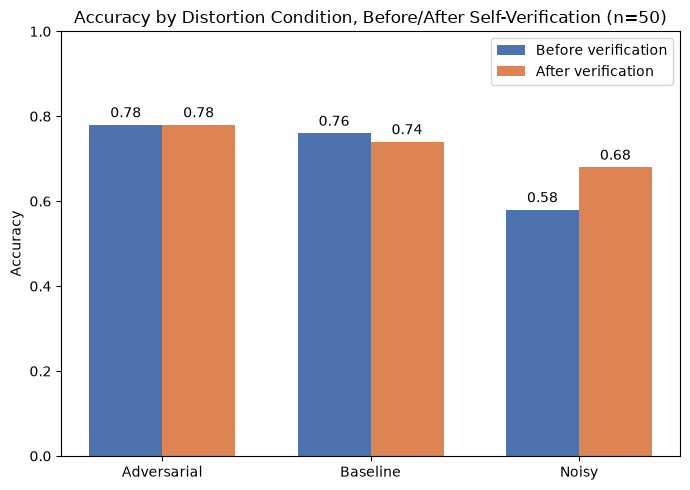

In [19]:
import matplotlib.pyplot as plt
import numpy as np

conditions = accuracy_summary.index.tolist()
first_pass = accuracy_summary["first_pass_accuracy"].values
final = accuracy_summary["final_accuracy"].values

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, first_pass, width, label="Before verification", color="#4C72B0")
bars2 = ax.bar(x + width/2, final, width, label="After verification", color="#DD8452")

ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Distortion Condition, Before/After Self-Verification (n=50)")
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in conditions])
ax.set_ylim(0, 1)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=3)
ax.bar_label(bars2, fmt="%.2f", padding=3)

plt.tight_layout()
plt.savefig("../results/accuracy_by_condition.png", dpi=200)
plt.show()

In [20]:
# One interesting case per verification_effect category, for noisy specifically
# -- this is where verification's effect is strongest, so the most
# illustrative examples for your paper live here
noisy_results = results[results["condition"] == "noisy"]

for effect in ["fixed_by_verification", "broken_by_verification"]:
    example_row = noisy_results[noisy_results["verification_effect"] == effect].iloc[0]
    print(f"=== {effect.upper()} ===")
    print("Question:", example_row["question"])
    print("Gold answer:", example_row["gold_answer"])
    print("First answer:  ", example_row["first_answer"])
    print("Final answer:  ", example_row["final_answer"])
    print()

=== FIXED_BY_VERIFICATION ===
Question: What nationality was Oliver Reed's character in the film Royal Flash?
Gold answer: Prussian
First answer:   German (he played Otto von Bismarck).
Final answer:   Upon re-reading the text, I see that Oliver Reed's character in the film Royal Flash was actually Otto von Bismarck, but according to the text, he played the role of Otto von Bismarck, not as himself.

However, the question asks about the nationality of Oliver Reed's character. According to the text, Otto von Bismarck was a Prussian statesman from Germany. Therefore:

Oliver Reed's character in the film Royal Flash was German (he played Otto von Bismarck).

=== BROKEN_BY_VERIFICATION ===
Question: The chorus of "On the Radio" contains references to the song "November Rain" whose band's lead singer is?
Gold answer: Axl Rose
First answer:   Axl Rose.
Final answer:   The text states that the chorus of "On the Radio" contains references to the song "November Rain", but it does not mention an

In [21]:
from src.evaluation.metrics import is_correct, classify_verification_effect

results = pd.read_csv("../results/experiment_results.csv")

print("=== OLD SCORING ===")
print(accuracy_summary)
print()

results["first_correct"] = results.apply(lambda r: is_correct(r["first_answer"], r["gold_answer"]), axis=1)
results["final_correct"] = results.apply(lambda r: is_correct(r["final_answer"], r["gold_answer"]), axis=1)
results["verification_effect"] = results.apply(lambda r: classify_verification_effect(r["first_correct"], r["final_correct"]), axis=1)
results.to_csv("../results/experiment_results.csv", index=False)

accuracy_summary = results.groupby("condition").agg(
    first_pass_accuracy=("first_correct", "mean"),
    final_accuracy=("final_correct", "mean"),
).round(3)

print("=== NEW SCORING (conclusion-only) ===")
print(accuracy_summary)
print()

verification_breakdown = results.groupby(["condition", "verification_effect"]).size().unstack(fill_value=0)
print("=== NEW VERIFICATION EFFECT BREAKDOWN ===")
print(verification_breakdown)

=== OLD SCORING ===
             first_pass_accuracy  final_accuracy
condition                                       
adversarial                 0.78            0.78
baseline                    0.76            0.74
noisy                       0.58            0.68

=== NEW SCORING (conclusion-only) ===
             first_pass_accuracy  final_accuracy
condition                                       
adversarial                 0.76            0.68
baseline                    0.76            0.66
noisy                       0.58            0.62

=== NEW VERIFICATION EFFECT BREAKDOWN ===
verification_effect  broken_by_verification  fixed_by_verification  \
condition                                                            
adversarial                               6                      2   
baseline                                  9                      4   
noisy                                     7                      9   

verification_effect  stayed_correct  stayed_wrong  
condi

In [22]:
from src.evaluation.metrics import is_self_contradictory

results["first_contradictory"] = results.apply(lambda r: is_self_contradictory(r["first_answer"], r["gold_answer"]), axis=1)
results["final_contradictory"] = results.apply(lambda r: is_self_contradictory(r["final_answer"], r["gold_answer"]), axis=1)
results.to_csv("../results/experiment_results.csv", index=False)

consistency_summary = results.groupby("condition").agg(
    first_contradiction_rate=("first_contradictory", "mean"),
    final_contradiction_rate=("final_contradictory", "mean"),
).round(3)

print("=== SELF-CONTRADICTION RATE BY CONDITION ===")
print(consistency_summary)
print()

contradictory_examples = results[results["final_contradictory"] == True]
if len(contradictory_examples) > 0:
    example_row = contradictory_examples.iloc[0]
    print("=== EXAMPLE ===")
    print("Question:", example_row["question"])
    print("Gold answer:", example_row["gold_answer"])
    print("Final answer (full):", example_row["final_answer"])
else:
    print("No self-contradictory final answers found in this run.")

=== SELF-CONTRADICTION RATE BY CONDITION ===
             first_contradiction_rate  final_contradiction_rate
condition                                                      
adversarial                      0.02                      0.14
baseline                         0.00                      0.08
noisy                            0.00                      0.06

=== EXAMPLE ===
Question: What nationality was Oliver Reed's character in the film Royal Flash?
Gold answer: Prussian
Final answer (full): Upon re-reading the text, I see that Oliver Reed's character in the film Royal Flash was actually Otto von Bismarck, but according to the text, he played the role of Otto von Bismarck, not as himself.

However, the question asks about the nationality of Oliver Reed's character. According to the text, Otto von Bismarck was a Prussian statesman from Germany. Therefore:

Oliver Reed's character in the film Royal Flash was German (he played Otto von Bismarck).
